# Building a Spiking Neural Network

BrainState provides the *substrate* for brain modeling — `State`, `Module`, integrators, delays,
and event-driven operators — but it deliberately ships few concrete neuron or synapse models.
Those live in the companion package **`brainpy`**, whose `brainpy.state` API is built directly on
BrainState. This is the intended cross-package workflow: import ready-made `LIF`, synapse, and
projection models from `brainpy.state`, and wire them together as ordinary BrainState modules.

We build a classic **excitatory–inhibitory (E/I) balanced network** one piece at a time, then run
it and plot the resulting spike raster.

In [1]:
import brainunit as u
import jax.numpy as jnp
import matplotlib.pyplot as plt

import brainstate
import brainpy
import braintools

brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)
brainstate.__version__

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


'0.4.0'

## Step 1: a population of spiking neurons

`brainpy.state.LIF` is a leaky integrate-and-fire population — a BrainState `Dynamics` module.
All physical quantities carry units (via `brainunit`): potentials in millivolts, time constants
in milliseconds. After `init_all_states`, the population is ready to be driven by an input
current.

In [2]:
neurons = brainpy.state.LIF(
    4,
    V_rest=-52. * u.mV,
    V_th=-50. * u.mV,
    V_reset=-60. * u.mV,
    tau=10. * u.ms,
    V_initializer=braintools.init.Constant(-60. * u.mV),
    spk_reset='soft',
)
brainstate.nn.init_all_states(neurons)

# Drive the neurons with a constant supra-threshold current for one step.
with brainstate.environ.context(t=0. * u.ms):
    spikes = neurons(8. * u.mA)
print('membrane potential:', neurons.V.value)
print('spikes this step  :', spikes)

membrane potential: [-59.84079742 -59.84079742 -59.84079742 -59.84079742] mV
spikes this step  : [0. 0. 0. 0.]


## Step 2: connecting populations with a projection

A **projection** carries spikes from a source population to a target. We assemble one from four
composable parts:

- a **communication** operator — `EventFixedProb`, the event-driven sparse connectivity from the
  [previous tutorial](03_event_driven_operators.ipynb);
- a **synapse** model — `Expon`, exponential conductance decay;
- an **output** model — `CUBA`, current-based synaptic input;
- the **postsynaptic** population.

`brainpy.state.AlignPostProj` binds them together. The `.desc(...)` calls are deferred
constructors that the projection instantiates against the target population.

In [3]:
projection = brainpy.state.AlignPostProj(
    comm=brainstate.nn.EventFixedProb(4, 4, conn_num=0.5, conn_weight=1.0 * u.mS),
    syn=brainpy.state.Expon.desc(4, tau=2. * u.ms),
    out=brainpy.state.CUBA.desc(),
    post=neurons,
)
print(type(projection).__name__, 'connects a source onto', neurons.varshape, 'neurons')

AlignPostProj connects a source onto (4,) neurons


## Step 3: assembling the E/I network

A balanced network has an excitatory and an inhibitory sub-population, each projecting onto the
whole network. We wrap a single `LIF` population (the first `n_exc` units are excitatory, the rest
inhibitory) and two projections in one `Module`. Its `update` reads the current spikes, routes
them through the two projections, then advances the neurons by one step.

In [4]:
class EINet(brainstate.nn.Module):
    def __init__(self, n_exc, n_inh, prob, JE, JI):
        super().__init__()
        self.n_exc = n_exc
        self.num = n_exc + n_inh
        self.N = brainpy.state.LIF(
            self.num,
            V_rest=-52. * u.mV, V_th=-50. * u.mV, V_reset=-60. * u.mV,
            tau=10. * u.ms,
            V_initializer=braintools.init.Normal(-60., 10., unit=u.mV),
            spk_reset='soft',
        )
        self.E = brainpy.state.AlignPostProj(
            comm=brainstate.nn.EventFixedProb(n_exc, self.num, prob, JE),
            syn=brainpy.state.Expon.desc(self.num, tau=2. * u.ms),
            out=brainpy.state.CUBA.desc(), post=self.N,
        )
        self.I = brainpy.state.AlignPostProj(
            comm=brainstate.nn.EventFixedProb(n_inh, self.num, prob, JI),
            syn=brainpy.state.Expon.desc(self.num, tau=2. * u.ms),
            out=brainpy.state.CUBA.desc(), post=self.N,
        )

    def update(self, inp):
        spikes = self.N.get_spike() != 0.
        self.E(spikes[:self.n_exc])     # excitatory spikes
        self.I(spikes[self.n_exc:])     # inhibitory spikes
        self.N(inp)                     # advance the neurons
        return self.N.get_spike()

## Step 4: running the simulation

We instantiate a 500-neuron network (400 excitatory, 100 inhibitory), initialise its state, and
step it for 200 ms under a constant background current. `brainstate.transform.for_loop` runs the
whole trajectory as a single compiled scan, collecting the spikes at every step.

In [5]:
n_exc, n_inh, prob = 400, 100, 0.1
# Balanced weights scale as 1/sqrt(expected number of inputs).
JE = 1. / u.math.sqrt(prob * n_exc) * u.mS
JI = -1. / u.math.sqrt(prob * n_inh) * u.mS

net = EINet(n_exc, n_inh, prob, JE, JI)
brainstate.nn.init_all_states(net)

times = u.math.arange(0. * u.ms, 200. * u.ms, brainstate.environ.get_dt())
spikes = brainstate.transform.for_loop(lambda t: net.update(3. * u.mA), times)
print('spike array shape (time, neurons):', spikes.shape)
print('total spikes:', int(jnp.sum(spikes != 0)))

spike array shape (time, neurons): (2000, 500)


total spikes: 4356


## Step 5: the spike raster

A raster plot — neuron index versus spike time — reveals the asynchronous irregular firing
characteristic of a balanced network.

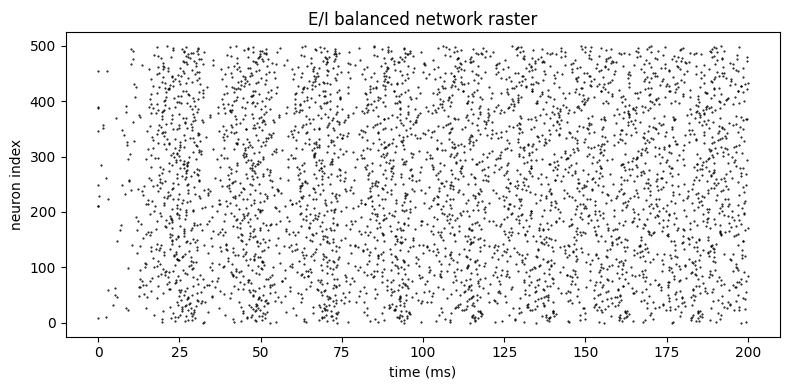

In [6]:
t_ms = times.to_decimal(u.ms)
t_idx, n_idx = u.math.where(spikes != 0)

plt.figure(figsize=(8, 4))
plt.plot(t_ms[t_idx], n_idx, 'k.', markersize=1)
plt.xlabel('time (ms)')
plt.ylabel('neuron index')
plt.title('E/I balanced network raster')
plt.tight_layout()
plt.show()

## Summary

- BrainState is the substrate; **`brainpy.state`** supplies concrete `LIF` neurons, `Expon`
  synapses, `CUBA` outputs, and `AlignPostProj` projections, all as BrainState modules.
- A projection composes a **communication** operator, a **synapse**, an **output**, and a
  **postsynaptic** population — here using the event-driven `EventFixedProb`.
- `init_all_states` prepares a network and `brainstate.transform.for_loop` runs the trajectory as
  one compiled scan.

### See also

- [Training a spiking neural network](05_training_an_snn.ipynb) — making such a network learn with surrogate gradients.
- [Event-driven operators](03_event_driven_operators.ipynb) — the connectivity used in the projections.
- The [brain-dynamics gallery](../../examples/brain_dynamics/index.rst) — complete simulation and Hodgkin–Huxley examples.